In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
url = (
    "https://raw.githubusercontent.com/AI-Learning-Repo/"
    "Data-Handling/refs/heads/week5/datasets/mall-customers.csv"
)
customers = pd.read_csv(url)

display(customers.head())
print("Rows and columns:", customers.shape)
customers.info()
print("Missing values per column:")
print(customers.isna().sum())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Rows and columns: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [3]:
feature_names = ["Annual Income (k$)", "Spending Score (1-100)"]
X_df = customers[feature_names].dropna().copy()
X = X_df.to_numpy()

print("Rows removed:", len(customers) - len(X_df))
print("Clustering data shape:", X.shape)

Rows removed: 0
Clustering data shape: (200, 2)


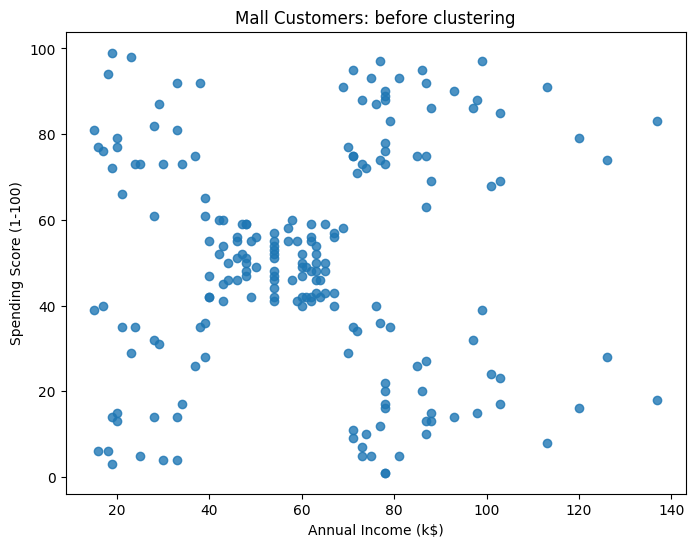

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.8)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customers: before clustering")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
print("First 20 cluster labels:", labels[:20])
print("Centroid array shape:", kmeans.cluster_centers_.shape)

First 20 cluster labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Centroid array shape: (3, 2)


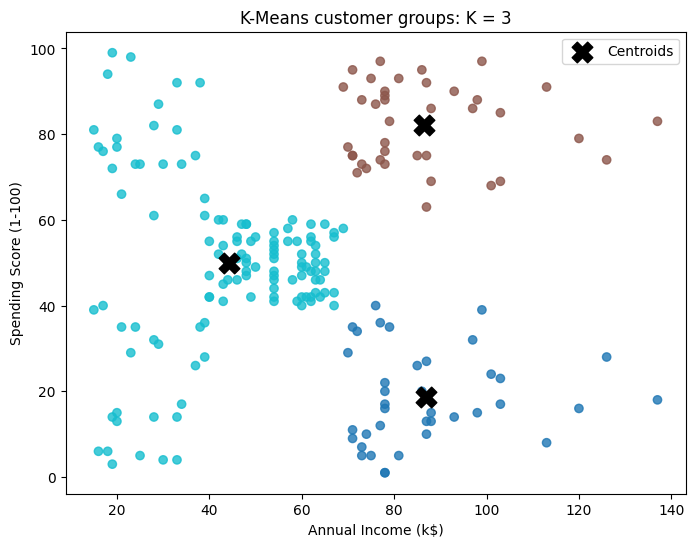

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,87.00,18.63
1,86.54,82.13
2,44.15,49.83


In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", alpha=0.8)
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    marker="X", s=220, c="black", label="Centroids"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means customer groups: K = 3")
plt.legend()
plt.show()

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)
centroids.index.name = "Cluster"
display(centroids.round(2))

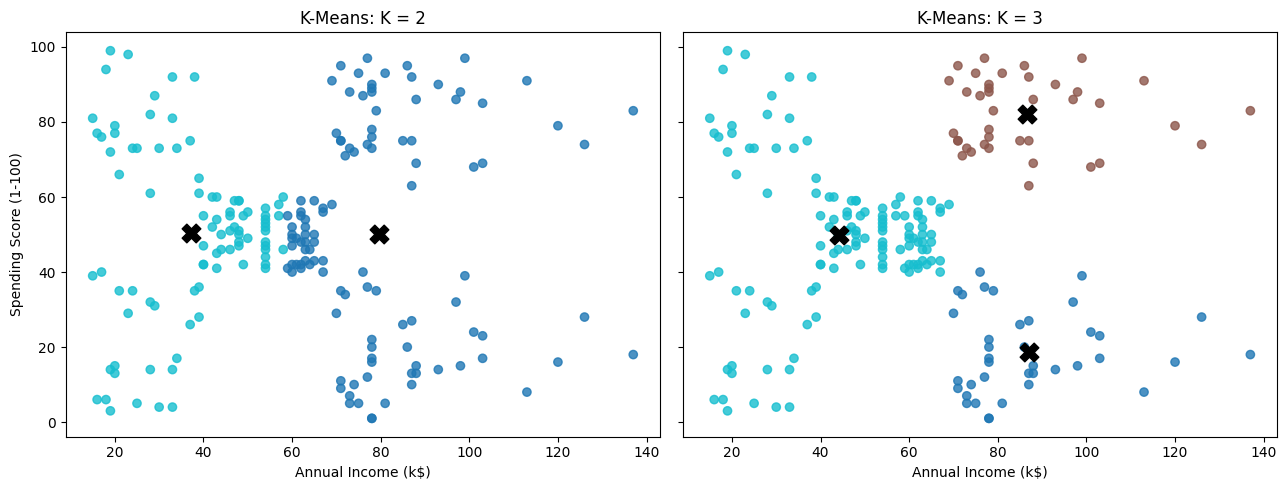

In [7]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, model, group_labels, k in [
    (axes[0], kmeans_2, labels_2, 2),
    (axes[1], kmeans, labels, 3)
]:
    ax.scatter(X[:, 0], X[:, 1], c=group_labels, cmap="tab10", alpha=0.8)
    ax.scatter(
        model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
        marker="X", s=180, c="black"
    )
    ax.set_xlabel("Annual Income (k$)")
    ax.set_title(f"K-Means: K = {k}")
axes[0].set_ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

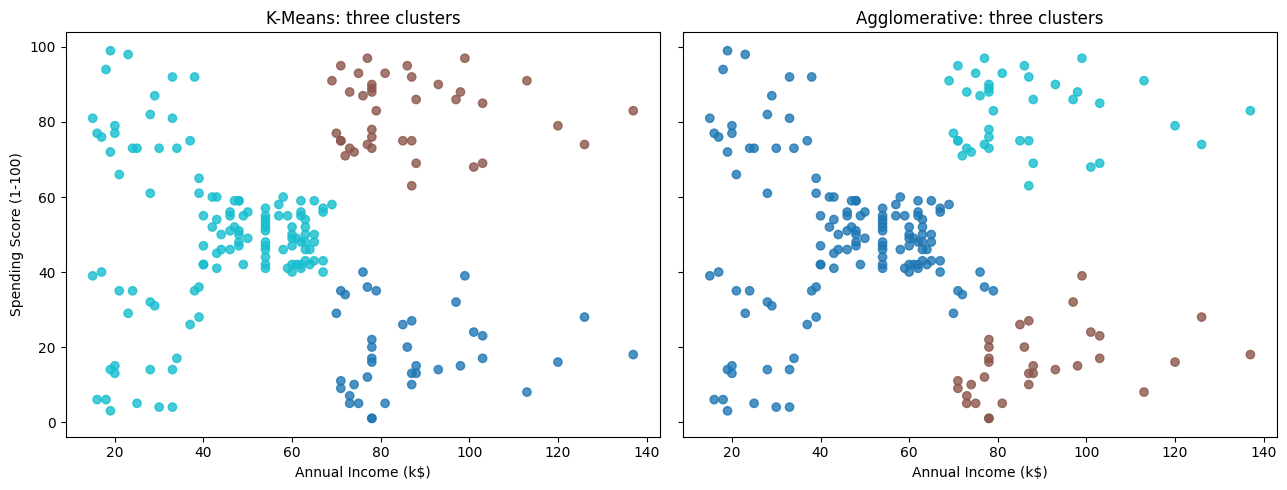

In [8]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
hierarchical_labels = hierarchical.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, group_labels, title in [
    (axes[0], labels, "K-Means: three clusters"),
    (axes[1], hierarchical_labels, "Agglomerative: three clusters")
]:
    ax.scatter(X[:, 0], X[:, 1], c=group_labels, cmap="tab10", alpha=0.8)
    ax.set_xlabel("Annual Income (k$)")
    ax.set_title(title)
axes[0].set_ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

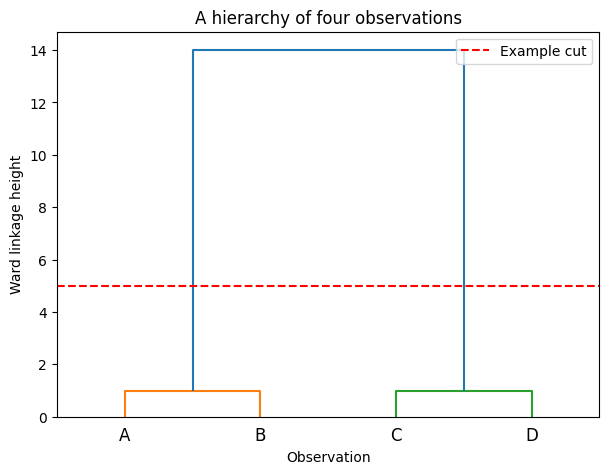

In [9]:
X_small = np.array([[1, 1], [1, 2], [8, 8], [8, 9]])
small_names = ["A", "B", "C", "D"]
Z_small = linkage(X_small, method="ward")

plt.figure(figsize=(7, 5))
dendrogram(Z_small, labels=small_names)
plt.axhline(y=5, color="red", linestyle="--", label="Example cut")
plt.xlabel("Observation")
plt.ylabel("Ward linkage height")
plt.title("A hierarchy of four observations")
plt.legend()
plt.show()

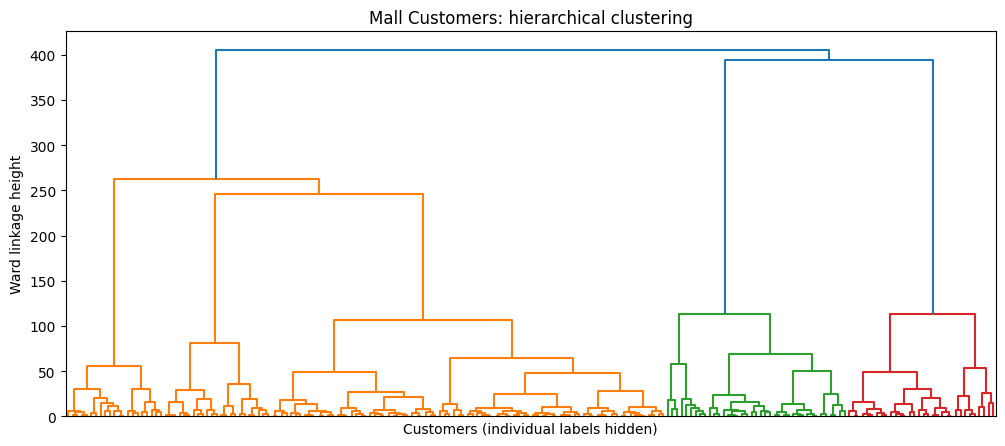

In [10]:
Z_customers = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z_customers, no_labels=True)
plt.xlabel("Customers (individual labels hidden)")
plt.ylabel("Ward linkage height")
plt.title("Mall Customers: hierarchical clustering")
plt.show()

In [11]:
clustered_customers = X_df.copy()
clustered_customers["Cluster"] = labels

profile = clustered_customers.groupby("Cluster")[feature_names].mean()
profile.insert(0, "Customers", clustered_customers.groupby("Cluster").size())
display(profile.round(2))

,Customers,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,38,87.00,18.63
1,39,86.54,82.13
2,123,44.15,49.83


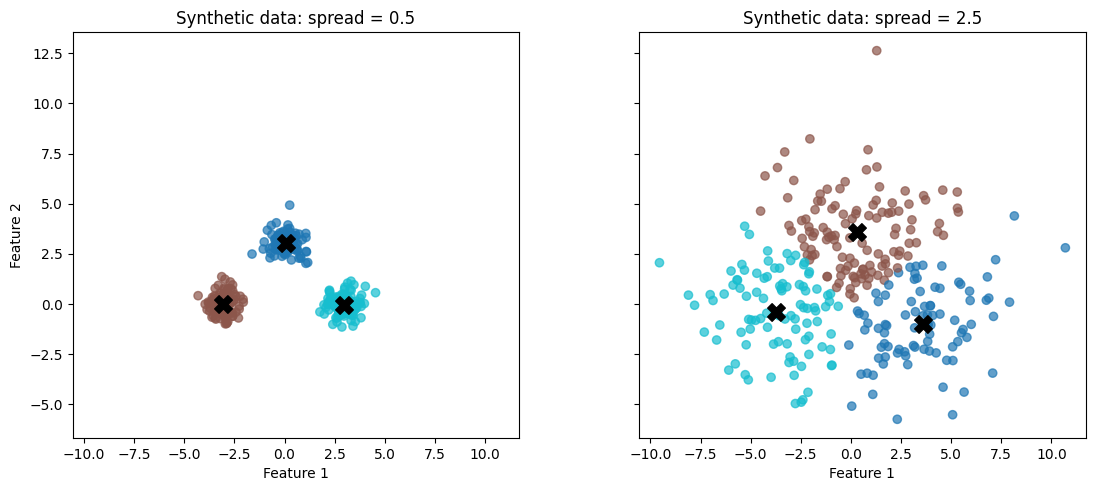

In [12]:
generation_centers = [[-3, 0], [0, 3], [3, 0]]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, spread in zip(axes, [0.5, 2.5]):
    X_demo, generation_labels = make_blobs(
        n_samples=300, centers=generation_centers,
        cluster_std=spread, random_state=42
    )
    demo_model = KMeans(n_clusters=3, random_state=42, n_init=10)
    demo_labels = demo_model.fit_predict(X_demo)
    ax.scatter(X_demo[:, 0], X_demo[:, 1], c=demo_labels, cmap="tab10", alpha=0.7)
    ax.scatter(
        demo_model.cluster_centers_[:, 0], demo_model.cluster_centers_[:, 1],
        marker="X", s=160, c="black"
    )
    ax.set_title(f"Synthetic data: spread = {spread}")
    ax.set_xlabel("Feature 1")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

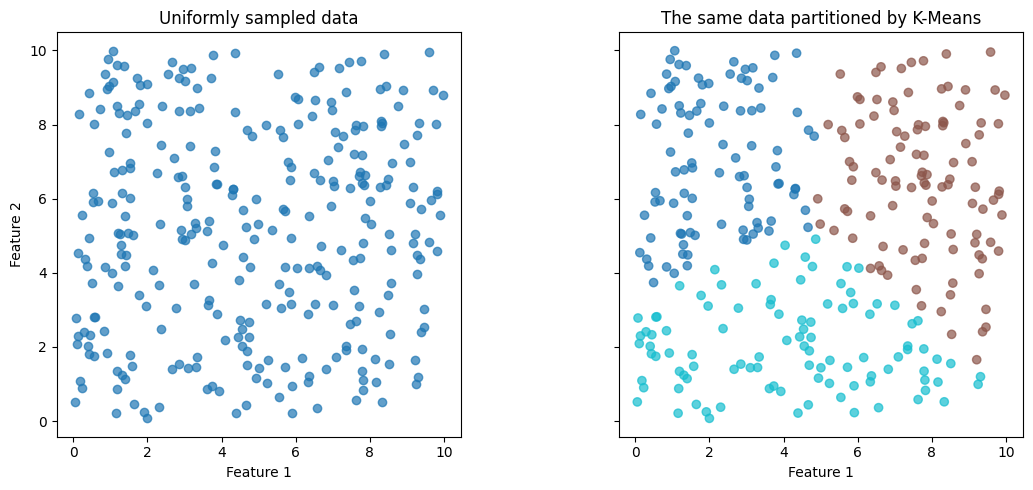

In [13]:
rng = np.random.default_rng(42)
X_random = rng.uniform(0, 10, size=(300, 2))
random_model = KMeans(n_clusters=3, random_state=42, n_init=10)
random_labels = random_model.fit_predict(X_random)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].scatter(X_random[:, 0], X_random[:, 1], alpha=0.7)
axes[0].set_title("Uniformly sampled data")
axes[1].scatter(
    X_random[:, 0], X_random[:, 1], c=random_labels, cmap="tab10", alpha=0.7
)
axes[1].set_title("The same data partitioned by K-Means")
for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("Feature 2")
plt.tight_layout()
plt.show()